# Batch Processing - 8 Participants

**Group Comparison: Young vs Aging**

Process all validated participants and compare resilience metrics.

**Author:** Victor SALVAT  
**Date:** 2026-03-31

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import sys
from scipy.signal import find_peaks

sys.path.append('../sources/python')

from load_data import load_pmocap_file
from preprocessing import preprocess_pipeline
from time_delay_embedding import compute_ami, compute_fnn, phase_space_reconstruction
from state_space import create_reference_trajectory, compute_euclidean_distances, compute_torus_thresholds
from perturbation_detection import detect_beeps, detect_perturbations
from resilience_metrics import compute_all_perturbation_metrics

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

print("✓ Setup complete")

✓ Setup complete


In [37]:
# Configuration
PARTICIPANT_IDS = ['004', '005', '006', '007', '008', '009', '010', '017']

GROUP_ASSIGNMENT = {
    '004': 'Young', '005': 'Young', '006': 'Aging', '007': 'Young',
    '008': 'Young', '009': 'Young', '010': 'Aging', '017': 'Young'
}

DATA_DIR = Path('../data/antoine')
RESULTS_DIR = Path('../results')
METRICS_DIR = RESULTS_DIR / 'metrics'
FIGURES_DIR = RESULTS_DIR / 'figures'

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Configuration: {len(PARTICIPANT_IDS)} participants")


✓ Configuration: 8 participants


In [38]:
def process_participant(pid: str) -> dict:
    """Process single participant."""
    try:
        # Load
        data = load_pmocap_file(str(DATA_DIR / f"{pid}_Cued.mat"))
        
        # Preprocess
        preprocessed = preprocess_pipeline(data['sacrum'], apply_emd=True, downsample_factor=4)
        sacrum_z = preprocessed['sacrum_z']
        fs = 100
        
        # TDE
        tau, ami = compute_ami(sacrum_z, max_lag=100)
        dim, fnn = compute_fnn(sacrum_z, max_dim=10, tau=tau)
        print(f"  P{pid}: τ={tau}, dim={dim}")
        
        # State-space (utilise dim optimal)
        state_space = phase_space_reconstruction(sacrum_z, tau, dim)
        
        # Perturbations
        beep_times, _ = detect_beeps(data['analog']['value'], fs=data['analog']['fs'])
        perturbations = detect_perturbations(beep_times)
        
        # Reference
        if not np.isnan(perturbations['slow_time']) and not np.isnan(perturbations['fast_time']):
            baseline_end_time = min(perturbations['slow_time'], perturbations['fast_time']) - 10
        elif not np.isnan(perturbations['slow_time']):
            baseline_end_time = perturbations['slow_time'] - 10
        elif not np.isnan(perturbations['fast_time']):
            baseline_end_time = perturbations['fast_time'] - 10
        else:
            baseline_end_time = 60
        
        baseline_end_idx = int(baseline_end_time * fs)
        reference = create_reference_trajectory(state_space, baseline_end_idx)
        
        # Distances
        distances = compute_euclidean_distances(state_space, reference, phase_matching=False)
        
        # Thresholds
        baseline_mask = np.arange(len(distances)) < baseline_end_idx
        thresholds = compute_torus_thresholds(distances, baseline_mask)
        
        # Steps
        steps, _ = find_peaks(-sacrum_z)
        
        # Metrics
        try:
            metrics = compute_all_perturbation_metrics(distances, thresholds, perturbations, steps, fs)
        except (IndexError, KeyError) as e:
            print(f"  ⚠ Warning: Metrics computation failed for P{pid}: {e}")
            metrics = {
                'slow': {'peak_value': np.nan, 'recovery_time': np.nan},
                'fast': {'peak_value': np.nan, 'recovery_time': np.nan}
            }
        
        return {
            'participant': pid,
            'group': GROUP_ASSIGNMENT[pid],
            'tau': tau,
            'dim': dim,
            'slow_peak': metrics.get('slow', {}).get('peak_value', np.nan),
            'slow_recovery': metrics.get('slow', {}).get('recovery_time', np.nan),
            'fast_peak': metrics.get('fast', {}).get('peak_value', np.nan),
            'fast_recovery': metrics.get('fast', {}).get('recovery_time', np.nan)
        }
    
    except Exception as e:
        print(f"✗ P{pid}: {e}")
        return {
            'participant': pid,
            'group': GROUP_ASSIGNMENT.get(pid, 'Unknown'),
            'tau': np.nan,
            'dim': np.nan,
            'slow_peak': np.nan,
            'slow_recovery': np.nan,
            'fast_peak': np.nan,
            'fast_recovery': np.nan
        }

In [39]:
# Process all
results = []

print("\nProcessing...\n" + "="*60)

for pid in tqdm(PARTICIPANT_IDS, desc="Progress"):
    try:
        result = process_participant(pid)
        results.append(result)
        print(f"✓ P{pid} ({result['group']}): τ={result['tau']}, d={result['dim']}")
    except Exception as e:
        print(f"✗ P{pid}: {str(e)}")

print("="*60)
print(f"\n✓ Processed {len(results)}/{len(PARTICIPANT_IDS)} participants")


Processing...


Progress:   0%|          | 0/8 [00:00<?, ?it/s]

Loading pMOCAP file: 004_Cued.mat
    Sacrum markers: 4 × 192000 samples
    Occluded samples: 23350 (3.04%)
    Analog signal: 240065 samples at 500.0 Hz
  ✓ Loaded successfully
    Participant: 004
    Duration: 480.00 s
    Sacrum fs: 400.0 Hz
    Analog fs: 500.0 Hz

PREPROCESSING PIPELINE

[1/5] Computing barycenter...
  Barycenter computed: (192000, 3)
    X range: [-1283.16, 1197.02] mm
    Y range: [-3341.05, 3243.84] mm
    Z range: [-50.68, 48.79] mm

[2/5] EMD decomposition...
  Applying EMD decomposition...
    Decomposed into 14 IMFs
    Combined IMFs [3, 4, 5, 6, 7, 8]
    Reconstructed signal: mean=0.58, std=16.43

[3/5] Butterworth filtering...
  Butterworth filter applied: 4th order, fc=5.0 Hz

[4/5] Downsampling...
  Downsampled by factor 4: 192000 → 48000 samples

[5/5] Creating time vector...

PREPROCESSING COMPLETE
  Original: 192000 samples @ 400.0 Hz
  Final: 48000 samples @ 100.0 Hz
  Duration: 479.99 seconds

  P004: τ=19, dim=5
  Detected 895 beeps
    First b

Progress:  12%|█▎        | 1/8 [01:20<09:23, 80.56s/it]


  Torus thresholds computed:
    T1 (1σ): 21.93 mm - Very stable: 79.5%
    T2 (2σ): 30.93 mm - Stable: 19.9%
    T3 (3σ): 39.94 mm - Unstable: 0.7%
    >T3:     Very unstable: 0.0%

COMPUTING RESILIENCE METRICS

[SLOW] Perturbation at t=173.54s
  Peak deviation: 26.42 mm at t=174.52s
  Recovery time: 0.00 s
  Steps to recovery: 0

[FAST] Perturbation at t=354.61s
  Peak deviation: 37.15 mm at t=356.83s
  Recovery time: 1.22 s
  Steps to recovery: 3


✓ P004 (Young): τ=19, d=5
Loading pMOCAP file: 005_Cued.mat
    Sacrum markers: 4 × 192000 samples
    Occluded samples: 55449 (7.22%)
    Analog signal: 240061 samples at 500.0 Hz
  ✓ Loaded successfully
    Participant: 005
    Duration: 480.00 s
    Sacrum fs: 400.0 Hz
    Analog fs: 500.0 Hz

PREPROCESSING PIPELINE

[1/5] Computing barycenter...
  Barycenter computed: (192000, 3)
    X range: [-1240.47, 1260.17] mm
    Y range: [-3673.47, 3604.78] mm
    Z range: [-56.37, 62.37] mm

[2/5] EMD decomposition...
  Applying EMD decomposi

...


  Torus thresholds computed:
    T1 (1σ): 25.50 mm - Very stable: 80.3%
    T2 (2σ): 36.34 mm - Stable: 18.6%
    T3 (3σ): 47.18 mm - Unstable: 1.1%
    >T3:     Very unstable: 0.0%

COMPUTING RESILIENCE METRICS

[SLOW] Perturbation at t=174.75s
  Peak deviation: 26.83 mm at t=179.40s
  Recovery time: 0.00 s
  Steps to recovery: 0

[FAST] Perturbation at t=355.26s
  Peak deviation: 37.94 mm at t=357.23s
  Recovery time: 0.02 s
  Steps to recovery: 0


✓ P009 (Young): τ=20, d=5
Loading pMOCAP file: 010_Cued.mat
    Sacrum markers: 4 × 192001 samples
    Occluded samples: 97169 (12.65%)
    Analog signal: 240065 samples at 500.0 Hz
  ✓ Loaded successfully
    Participant: 010
    Duration: 480.00 s
    Sacrum fs: 400.0 Hz
    Analog fs: 500.0 Hz

PREPROCESSING PIPELINE

[1/5] Computing barycenter...
  Barycenter computed: (192001, 3)
    X range: [-1757.83, 1451.73] mm
    Y range: [-3678.04, 3599.67] mm
    Z range: [-46.79, 55.56] mm

[2/5] EMD decomposition...
  Applying EMD decompos

Progress:  88%|████████▊ | 7/8 [09:57<01:26, 86.89s/it]


  Torus thresholds computed:
    T1 (1σ): 11.86 mm - Very stable: 83.5%
    T2 (2σ): 16.84 mm - Stable: 14.1%
    T3 (3σ): 21.82 mm - Unstable: 1.8%
    >T3:     Very unstable: 0.6%

COMPUTING RESILIENCE METRICS

[SLOW] Perturbation at t=174.08s
  Peak deviation: 13.92 mm at t=176.10s
  Recovery time: 0.00 s
  Steps to recovery: 0

[FAST] Perturbation at t=355.30s
  Peak deviation: 14.56 mm at t=360.14s
  Recovery time: 11.46 s
  Steps to recovery: 20


✓ P010 (Aging): τ=20, d=5
Loading pMOCAP file: 017_Cued.mat
    Sacrum markers: 4 × 189597 samples
    Occluded samples: 36771 (4.85%)
    Analog signal: 237004 samples at 500.0 Hz
  ✓ Loaded successfully
    Participant: 017
    Duration: 473.99 s
    Sacrum fs: 400.0 Hz
    Analog fs: 500.0 Hz

PREPROCESSING PIPELINE

[1/5] Computing barycenter...
  Barycenter computed: (189597, 3)
    X range: [-1419.61, 1307.84] mm
    Y range: [-3514.94, 3569.95] mm
    Z range: [-45.93, 42.42] mm

[2/5] EMD decomposition...
  Applying EMD decompo

Progress: 100%|██████████| 8/8 [11:23<00:00, 85.43s/it]


  Torus thresholds computed:
    T1 (1σ): 16.25 mm - Very stable: 87.7%
    T2 (2σ): 22.97 mm - Stable: 8.3%
    T3 (3σ): 29.68 mm - Unstable: 2.4%
    >T3:     Very unstable: 1.5%

COMPUTING RESILIENCE METRICS

[SLOW] Perturbation at t=167.17s
  Peak deviation: 40.69 mm at t=169.90s
  Recovery time: 4.46 s
  Steps to recovery: 7

[FAST] Perturbation at t=345.72s
  Peak deviation: 24.97 mm at t=350.05s
  Recovery time: 0.04 s
  Steps to recovery: 1


✓ P017 (Young): τ=21, d=5

✓ Processed 8/8 participants


In [42]:
data_rows = []

for r in results:
    row = {
        'Participant': r['participant'],
        'Group': r['group'],
        'Slow_Peak': r.get('slow_peak', np.nan),
        'Slow_Recovery': r.get('slow_recovery', np.nan),
        'Fast_Peak': r.get('fast_peak', np.nan),
        'Fast_Recovery': r.get('fast_recovery', np.nan),
    }
    data_rows.append(row)

df = pd.DataFrame(data_rows)

print("\n✓ Results:")
print(df.to_string(index=False))

output_path = METRICS_DIR / 'all_participants.csv'
df.to_csv(output_path, index=False)
print(f"\n✓ Saved: {output_path}")


✓ Results:
Participant Group  Slow_Peak  Slow_Recovery  Fast_Peak  Fast_Recovery
        004 Young  26.424571           0.00  37.150039           1.22
        005 Young  24.812525          30.32  32.362701           6.00
        006 Aging  30.149662          18.52  39.387221          15.21
        007 Young        NaN            NaN        NaN            NaN
        008 Young  28.536580           0.10  31.758290          15.32
        009 Young  26.829572           0.00  37.943414           0.02
        010 Aging  13.917288           0.00  14.560537          11.46
        017 Young  40.690064           4.46  24.966330           0.04

✓ Saved: ..\results\metrics\all_participants.csv


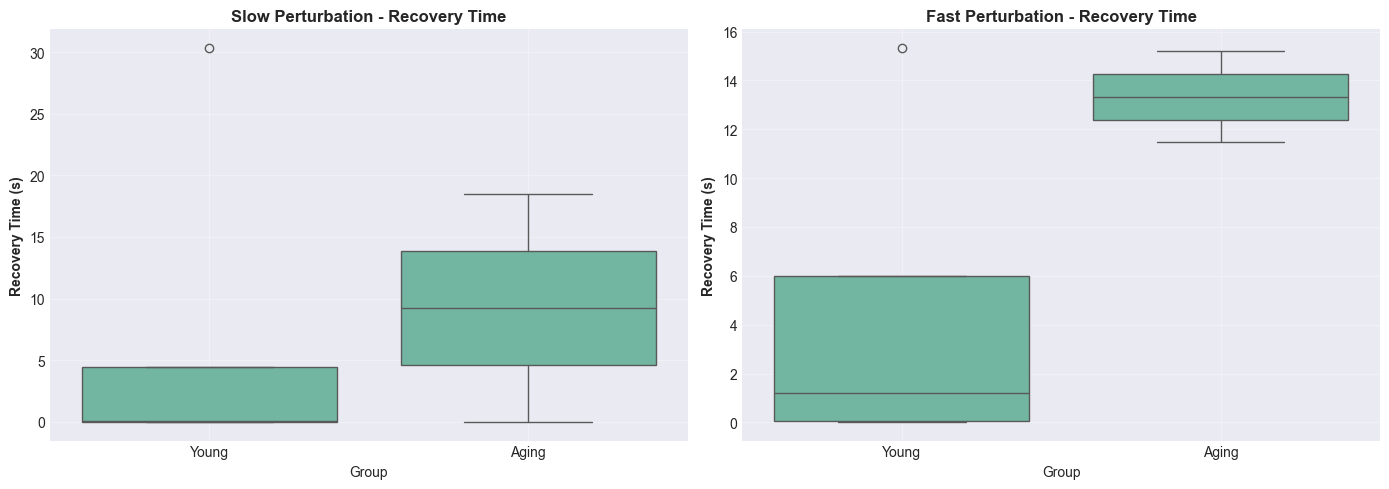

✓ Recovery time comparison plotted


In [43]:
# Plot: Recovery times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Group', y='Slow_Recovery', ax=axes[0])
axes[0].set_title('Slow Perturbation - Recovery Time', fontweight='bold')
axes[0].set_ylabel('Recovery Time (s)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

sns.boxplot(data=df, x='Group', y='Fast_Recovery', ax=axes[1])
axes[1].set_title('Fast Perturbation - Recovery Time', fontweight='bold')
axes[1].set_ylabel('Recovery Time (s)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'recovery_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Recovery time comparison plotted")

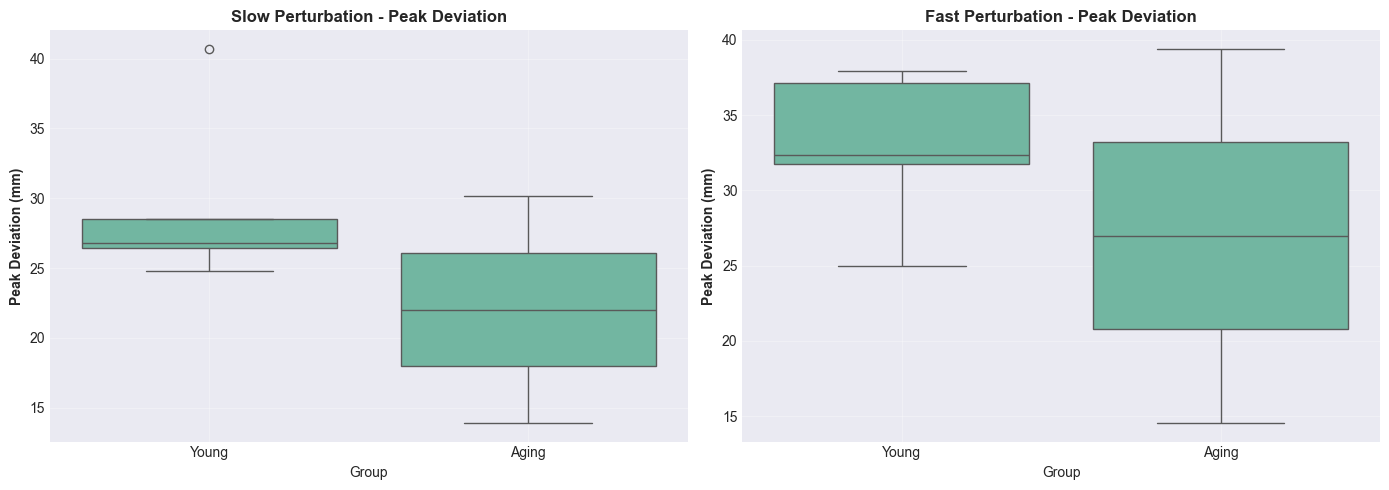

✓ Peak deviation comparison plotted


In [44]:
# Plot: Peak deviations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Group', y='Slow_Peak', ax=axes[0])
axes[0].set_title('Slow Perturbation - Peak Deviation', fontweight='bold')
axes[0].set_ylabel('Peak Deviation (mm)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

sns.boxplot(data=df, x='Group', y='Fast_Peak', ax=axes[1])
axes[1].set_title('Fast Perturbation - Peak Deviation', fontweight='bold')
axes[1].set_ylabel('Peak Deviation (mm)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'peak_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Peak deviation comparison plotted")

In [45]:
# Summary statistics
summary = df.groupby('Group').agg({
    'Slow_Recovery': ['mean', 'std', 'min', 'max'],
    'Slow_Peak': ['mean', 'std', 'min', 'max'],
    'Fast_Recovery': ['mean', 'std', 'min', 'max'],
    'Fast_Peak': ['mean', 'std', 'min', 'max'],
}).round(2)

print("\n" + "="*80)
print("SUMMARY STATISTICS BY GROUP")
print("="*80)
print(summary)
print("="*80)


SUMMARY STATISTICS BY GROUP
      Slow_Recovery                    Slow_Peak                       \
               mean    std  min    max      mean    std    min    max   
Group                                                                   
Aging          9.26  13.10  0.0  18.52     22.03  11.48  13.92  30.15   
Young          6.98  13.19  0.0  30.32     29.46   6.42  24.81  40.69   

      Fast_Recovery                     Fast_Peak                       
               mean   std    min    max      mean    std    min    max  
Group                                                                   
Aging         13.34  2.65  11.46  15.21     26.97  17.56  14.56  39.39  
Young          4.52  6.52   0.02  15.32     32.84   5.20  24.97  37.94  
